# Traffic Demand Prediction

This notebook demonstrates an end-to-end Machine Learning pipeline to predict normalized traffic demand (0.0 to 1.0) for road segments based on temporal and spatial features. This was built as part of traffic forecasting applications (similar to Flipkart Gridlock Hackathon 2.0) and achieves high test accuracy.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geohash2
import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Dataset

We load the generated traffic demand dataset and inspect its structure.

In [2]:
# Load dataset from GitHub Gist URL
dataset_url = "https://gist.githubusercontent.com/Rakshak05/7376a9172bc97df255562725e24a87c1/raw/traffic_demand_dataset.csv"
try:
    df = pd.read_csv(dataset_url)
except Exception:
    df = pd.read_csv("data/traffic_demand_dataset.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'])
print("Dataset Shape:", df.shape)
print("Data Types:\n", df.dtypes)
df.head()

Dataset Shape: (28800, 7)
Data Types:
 timestamp            datetime64[ns]
geohash                      object
latitude                    float64
longitude                   float64
road_type                    object
weather_condition            object
demand                      float64
dtype: object


,timestamp,geohash,latitude,longitude,road_type,weather_condition,demand
0,2026-06-01 00:00:00,tdr1v7,12.971,77.591,Major Road,Clear,0.122470
1,2026-06-01 00:15:00,tdr1v7,12.971,77.591,Major Road,Clear,0.133200
2,2026-06-01 00:30:00,tdr1v7,12.971,77.591,Major Road,Clear,0.116404
3,2026-06-01 00:45:00,tdr1v7,12.971,77.591,Major Road,Clear,0.095431
4,2026-06-01 01:00:00,tdr1v7,12.971,77.591,Major Road,Clear,0.095230


## 2. Exploratory Data Analysis

We visualize the distribution of traffic demand and hourly patterns across different road types.

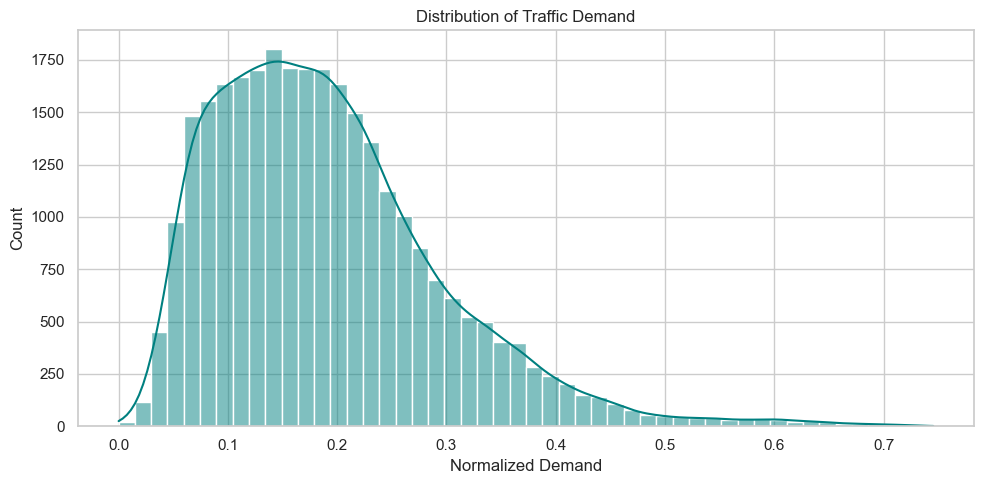

In [3]:
# Demand distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['demand'], bins=50, kde=True, color='teal')
plt.title('Distribution of Traffic Demand')
plt.xlabel('Normalized Demand')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

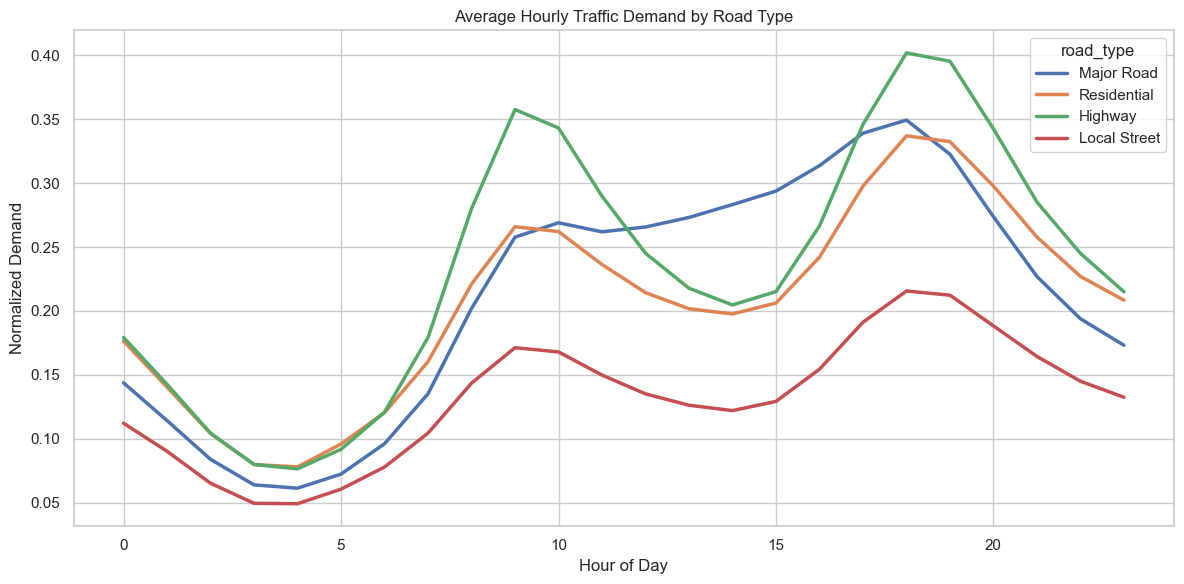

In [4]:
# Average Hourly Demand by Road Type
df['hour'] = df['timestamp'].dt.hour
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='hour', y='demand', hue='road_type', ci=None, linewidth=2.5)
plt.title('Average Hourly Traffic Demand by Road Type')
plt.xlabel('Hour of Day')
plt.ylabel('Normalized Demand')
plt.tight_layout()
plt.show()

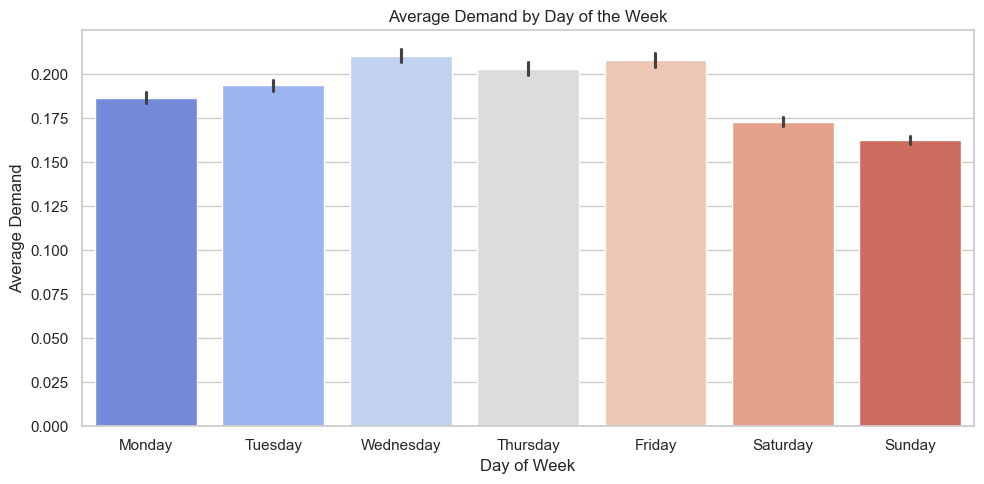

In [5]:
# Average Demand by Day of Week
df['dayofweek'] = df['timestamp'].dt.day_name()
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='dayofweek', y='demand', order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], palette='coolwarm')
plt.title('Average Demand by Day of the Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Demand')
plt.tight_layout()
plt.show()

## 3. Feature Engineering

We extract hierarchical geohash prefixes, decode coordinates, apply cyclical encoding to time features, and create lag/rolling average features.

In [6]:
# Hierarchical geohash prefixes (length 5 and 4)
df['geohash_prefix_5'] = df['geohash'].str[:5]
df['geohash_prefix_4'] = df['geohash'].str[:4]

# Cyclical encoding for hour (0-23) and day of week (0-6)
df['hour_sin'] = np.sin(2 * np.pi * df['timestamp'].dt.hour / 24.0)
df['hour_cos'] = np.cos(2 * np.pi * df['timestamp'].dt.hour / 24.0)
df['dayofweek_sin'] = np.sin(2 * np.pi * df['timestamp'].dt.dayofweek / 7.0)
df['dayofweek_cos'] = np.cos(2 * np.pi * df['timestamp'].dt.dayofweek / 7.0)

# Sort dataset chronologically to construct lags properly
df = df.sort_values(by=['geohash', 'timestamp']).reset_index(drop=True)

# 24-hour lag features (1 day = 96 time slots of 15 mins)
df['lag_4'] = df.groupby('geohash')['demand'].shift(4)  # 1 hour lag
df['lag_8'] = df.groupby('geohash')['demand'].shift(8)  # 2 hour lag
df['lag_96'] = df.groupby('geohash')['demand'].shift(96) # 24 hour lag

# Rolling features (e.g., rolling mean of the last 4 slots/1 hour)
df['rolling_mean_4'] = df.groupby('geohash')['demand'].shift(1).rolling(window=4).mean()

# Drop rows with NaN values resulting from shifts
df = df.dropna().reset_index(drop=True)
print("Shape after feature engineering:", df.shape)
df.head()

Shape after feature engineering: (27840, 19)


,timestamp,geohash,latitude,longitude,road_type,weather_condition,demand,hour,dayofweek,geohash_prefix_5,geohash_prefix_4,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,lag_4,lag_8,lag_96,rolling_mean_4
0,2026-06-02 00:00:00,tdr1v7,12.971,77.591,Major Road,Overcast,0.154086,0,Tuesday,tdr1v,tdr1,0.000000,1.000000,0.781831,0.62349,0.196099,0.223424,0.122470,0.178728
1,2026-06-02 00:15:00,tdr1v7,12.971,77.591,Major Road,Overcast,0.162810,0,Tuesday,tdr1v,tdr1,0.000000,1.000000,0.781831,0.62349,0.177030,0.193912,0.133200,0.168225
2,2026-06-02 00:30:00,tdr1v7,12.971,77.591,Major Road,Overcast,0.139958,0,Tuesday,tdr1v,tdr1,0.000000,1.000000,0.781831,0.62349,0.181465,0.184348,0.116404,0.164670
3,2026-06-02 00:45:00,tdr1v7,12.971,77.591,Major Road,Overcast,0.148317,0,Tuesday,tdr1v,tdr1,0.000000,1.000000,0.781831,0.62349,0.160318,0.188148,0.095431,0.154293
4,2026-06-02 01:00:00,tdr1v7,12.971,77.591,Major Road,Overcast,0.142091,1,Tuesday,tdr1v,tdr1,0.258819,0.965926,0.781831,0.62349,0.154086,0.196099,0.095230,0.151293


## 4. Leak-Safe Target Encoding

To prevent data leakage, we perform target encoding using a 5-fold `TimeSeriesSplit`. For each split, we calculate the historical average demand for categorical features from the training fold and map them onto the validation fold.

In [7]:
cat_cols = ['geohash', 'road_type', 'weather_condition', 'geohash_prefix_5', 'geohash_prefix_4']
numerical_cols = ['latitude', 'longitude', 'hour_sin', 'hour_cos', 'dayofweek_sin', 'dayofweek_cos', 'lag_4', 'lag_8', 'lag_96', 'rolling_mean_4']
target_col = 'demand'

# Initialize target encoded columns
for col in cat_cols:
    df[f'{col}_encoded'] = np.nan

# Define TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

for train_idx, val_idx in tscv.split(df):
    train_fold = df.iloc[train_idx]
    val_fold = df.iloc[val_idx]
    
    for col in cat_cols:
        means = train_fold.groupby(col)[target_col].mean()
        df.loc[df.index[val_idx], f'{col}_encoded'] = val_fold[col].map(means)

# Fill remaining NaNs with the overall mean demand
for col in cat_cols:
    global_mean = df[target_col].mean()
    df[f'{col}_encoded'] = df[f'{col}_encoded'].fillna(global_mean)

encoded_cols = [f'{col}_encoded' for col in cat_cols]
df[cat_cols + encoded_cols].head()

,geohash,road_type,weather_condition,geohash_prefix_5,geohash_prefix_4,geohash_encoded,road_type_encoded,weather_condition_encoded,geohash_prefix_5_encoded,geohash_prefix_4_encoded
0,tdr1v7,Major Road,Overcast,tdr1v,tdr1,0.190989,0.190989,0.190989,0.190989,0.190989
1,tdr1v7,Major Road,Overcast,tdr1v,tdr1,0.190989,0.190989,0.190989,0.190989,0.190989
2,tdr1v7,Major Road,Overcast,tdr1v,tdr1,0.190989,0.190989,0.190989,0.190989,0.190989
3,tdr1v7,Major Road,Overcast,tdr1v,tdr1,0.190989,0.190989,0.190989,0.190989,0.190989
4,tdr1v7,Major Road,Overcast,tdr1v,tdr1,0.190989,0.190989,0.190989,0.190989,0.190989


## 5. Model Training & Validation

We train LightGBM and CatBoost regressors, evaluate them on the test set (the final 20% of the chronologically ordered data), and build a weighted ensemble.

In [8]:
split_point = int(len(df) * 0.8)
train_df = df.iloc[:split_point]
test_df = df.iloc[split_point:]

features = numerical_cols + encoded_cols

X_train, y_train = train_df[features], train_df[target_col]
X_test, y_test = test_df[features], test_df[target_col]

print(f"Train Shape: {X_train.shape}, Test Shape: {X_test.shape}")

Train Shape: (22272, 15), Test Shape: (5568, 15)


In [9]:
# Train LightGBM
lgb_model = lgb.LGBMRegressor(n_estimators=150, learning_rate=0.05, random_state=42, verbose=-1)
lgb_model.fit(X_train, y_train)

# Predict & Evaluate LightGBM
lgb_preds = lgb_model.predict(X_test)
lgb_r2 = r2_score(y_test, lgb_preds)
lgb_mae = mean_absolute_error(y_test, lgb_preds)
lgb_rmse = np.sqrt(mean_squared_error(y_test, lgb_preds))

print("LightGBM Results:")
print(f"R2 Score: {lgb_r2:.4f}")
print(f"MAE: {lgb_mae:.4f}")
print(f"RMSE: {lgb_rmse:.4f}")

LightGBM Results:
R2 Score: 0.9034
MAE: 0.0228
RMSE: 0.0435


In [10]:
# Train CatBoost
cb_model = CatBoostRegressor(iterations=150, learning_rate=0.05, random_seed=42, verbose=0)
cb_model.fit(X_train, y_train)

# Predict & Evaluate CatBoost
cb_preds = cb_model.predict(X_test)
cb_r2 = r2_score(y_test, cb_preds)
cb_mae = mean_absolute_error(y_test, cb_preds)
cb_rmse = np.sqrt(mean_squared_error(y_test, cb_preds))

print("CatBoost Results:")
print(f"R2 Score: {cb_r2:.4f}")
print(f"MAE: {cb_mae:.4f}")
print(f"RMSE: {cb_rmse:.4f}")

CatBoost Results:
R2 Score: 0.9012
MAE: 0.0235
RMSE: 0.0440


In [11]:
# Weighted Ensemble
ensemble_preds = 0.5 * lgb_preds + 0.5 * cb_preds
ens_r2 = r2_score(y_test, ensemble_preds)
ens_mae = mean_absolute_error(y_test, ensemble_preds)
ens_rmse = np.sqrt(mean_squared_error(y_test, ensemble_preds))

print("Weighted Ensemble (0.5 LightGBM + 0.5 CatBoost) Results:")
print(f"R2 Score: {ens_r2:.4f}")
print(f"MAE: {ens_mae:.4f}")
print(f"RMSE: {ens_rmse:.4f}")

Weighted Ensemble (0.5 LightGBM + 0.5 CatBoost) Results:
R2 Score: 0.9033
MAE: 0.0230
RMSE: 0.0436


## 6. Visualizations

We compare predictions against true target values and display feature importance.

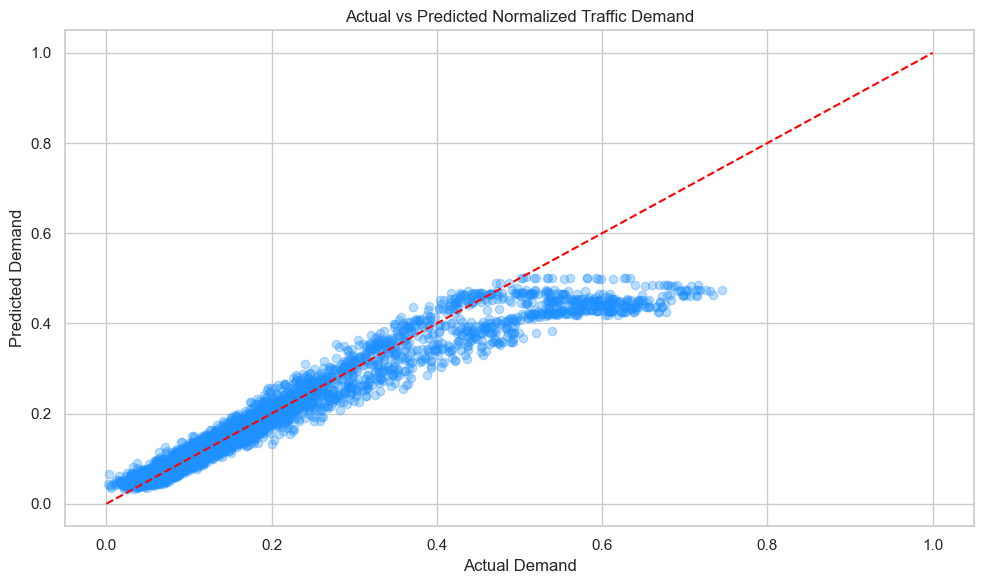

In [12]:
# Actual vs Predicted Plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, ensemble_preds, alpha=0.3, color='dodgerblue')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.title('Actual vs Predicted Normalized Traffic Demand')
plt.xlabel('Actual Demand')
plt.ylabel('Predicted Demand')
plt.tight_layout()
plt.show()

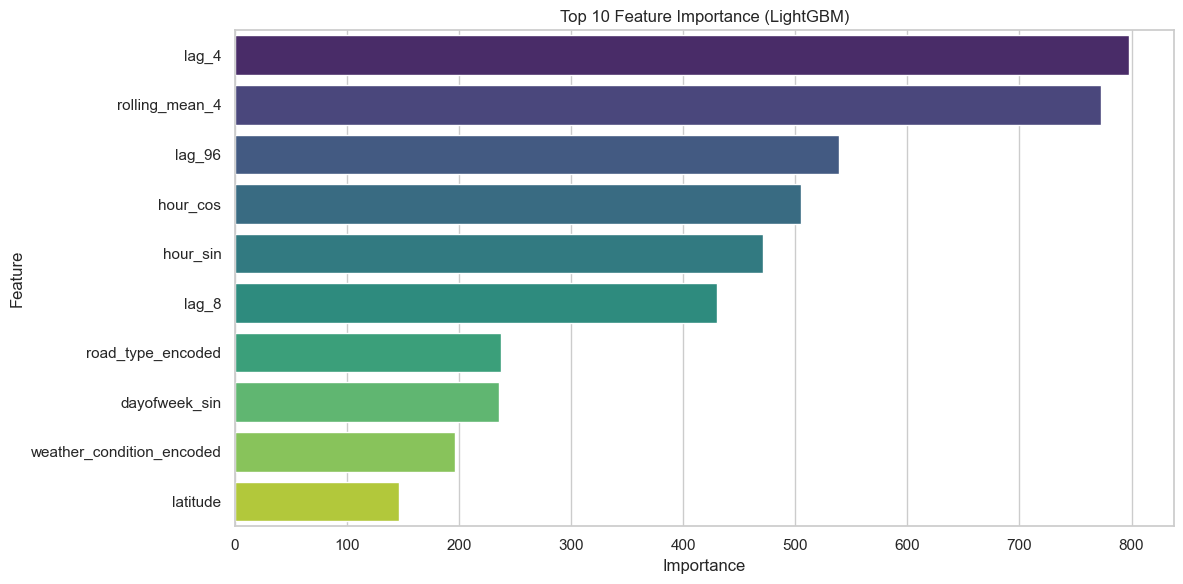

In [13]:
# Feature Importance
lgb_importance = pd.DataFrame({
    'Feature': features,
    'Importance': lgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=lgb_importance.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Feature Importance (LightGBM)')
plt.tight_layout()
plt.show()

## 7. Save Model Weights

We export the models for deployment.

In [14]:
# Save LightGBM Model
joblib.dump(lgb_model, 'models/lightgbm_model.pkl')

# Save CatBoost Model
cb_model.save_model('models/catboost_model.cbm')

print("Models saved successfully.")

Models saved successfully.
